In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device :",device)

Using Device : cpu


In [8]:
df = pd.read_csv('D:\mca_aiml_lab\mca_env\Datasets\BHARTIARTL.csv')

df.head()

<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_17964\2929416509.py:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  df = pd.read_csv('D:\mca_aiml_lab\mca_env\Datasets\BHARTIARTL.csv')


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2002-02-18,BHARTI,EQ,0.00,51.90,51.90,43.50,44.70,44.35,46.00,10381190,4.775431e+13,NaN,6503775.0,0.6265
1,2002-02-19,BHARTI,EQ,44.35,45.15,45.15,41.30,41.35,41.70,42.58,3552660,1.512609e+13,NaN,1741184.0,0.4901
2,2002-02-20,BHARTI,EQ,41.70,40.60,42.80,40.25,41.20,41.25,41.56,2512964,1.044348e+13,NaN,NaN,NaN
3,2002-02-21,BHARTI,EQ,41.25,42.85,43.40,42.15,42.20,42.40,42.76,1338196,5.722681e+12,NaN,485969.0,0.3632
4,2002-02-22,BHARTI,EQ,42.40,42.65,43.60,41.10,43.35,43.30,42.75,811327,3.468413e+12,NaN,399133.0,0.4920


In [4]:
df.shape

(4774, 15)

In [9]:
# Convert Date column
df['DateTime'] = pd.to_datetime(df['Date'].astype(str), errors='coerce')
df = df.sort_values("DateTime").reset_index(drop=True)
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,DateTime
0,2002-02-18,BHARTI,EQ,0.00,51.90,51.90,43.50,44.70,44.35,46.00,10381190,4.775431e+13,NaN,6503775.0,0.6265,2002-02-18
1,2002-02-19,BHARTI,EQ,44.35,45.15,45.15,41.30,41.35,41.70,42.58,3552660,1.512609e+13,NaN,1741184.0,0.4901,2002-02-19
2,2002-02-20,BHARTI,EQ,41.70,40.60,42.80,40.25,41.20,41.25,41.56,2512964,1.044348e+13,NaN,NaN,NaN,2002-02-20
3,2002-02-21,BHARTI,EQ,41.25,42.85,43.40,42.15,42.20,42.40,42.76,1338196,5.722681e+12,NaN,485969.0,0.3632,2002-02-21
4,2002-02-22,BHARTI,EQ,42.40,42.65,43.60,41.10,43.35,43.30,42.75,811327,3.468413e+12,NaN,399133.0,0.4920,2002-02-22


In [13]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.ffill().bfill()



In [14]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,DateTime
0,2002-02-18,BHARTI,EQ,0.00,51.90,51.90,43.50,44.70,44.35,46.00,10381190,4.775431e+13,47549.0,6503775.0,0.6265,2002-02-18
1,2002-02-19,BHARTI,EQ,44.35,45.15,45.15,41.30,41.35,41.70,42.58,3552660,1.512609e+13,47549.0,1741184.0,0.4901,2002-02-19
2,2002-02-20,BHARTI,EQ,41.70,40.60,42.80,40.25,41.20,41.25,41.56,2512964,1.044348e+13,47549.0,1741184.0,0.4901,2002-02-20
3,2002-02-21,BHARTI,EQ,41.25,42.85,43.40,42.15,42.20,42.40,42.76,1338196,5.722681e+12,47549.0,485969.0,0.3632,2002-02-21
4,2002-02-22,BHARTI,EQ,42.40,42.65,43.60,41.10,43.35,43.30,42.75,811327,3.468413e+12,47549.0,399133.0,0.4920,2002-02-22


In [15]:
df.isnull().sum()

Date                  0
Symbol                0
Series                0
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
%Deliverble           0
DateTime              0
dtype: int64

In [23]:
numeric_df = df.iloc[:,3:-2] # Exclude 'Date', 'Symbol', 'Series', and 'DateTime' columns


In [24]:
numeric_df

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
0,0.00,51.90,51.90,43.50,44.70,44.35,46.00,10381190,4.775431e+13,47549.0,6503775.0
1,44.35,45.15,45.15,41.30,41.35,41.70,42.58,3552660,1.512609e+13,47549.0,1741184.0
2,41.70,40.60,42.80,40.25,41.20,41.25,41.56,2512964,1.044348e+13,47549.0,1741184.0
3,41.25,42.85,43.40,42.15,42.20,42.40,42.76,1338196,5.722681e+12,47549.0,485969.0
4,42.40,42.65,43.60,41.10,43.35,43.30,42.75,811327,3.468413e+12,47549.0,399133.0
...,...,...,...,...,...,...,...,...,...,...,...
4769,522.60,522.75,528.50,522.75,527.20,527.55,526.12,5819893,3.061971e+14,70201.0,2682701.0
4770,527.55,527.45,538.55,526.25,535.50,534.30,534.45,9693047,5.180449e+14,99563.0,3413478.0
4771,534.30,535.95,548.00,535.60,543.75,544.30,542.82,11970652,6.497866e+14,125600.0,4344243.0
4772,544.30,549.70,550.00,539.10,540.20,540.85,542.81,8683857,4.713694e+14,98579.0,3138384.0


In [25]:
# Convert df to numpy

features_names = numeric_df.columns.tolist()

num_features = len(features_names)

print("Features:", features_names)
print("Number of features:", num_features)



Features: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']
Number of features: 11


#### Visualize time series

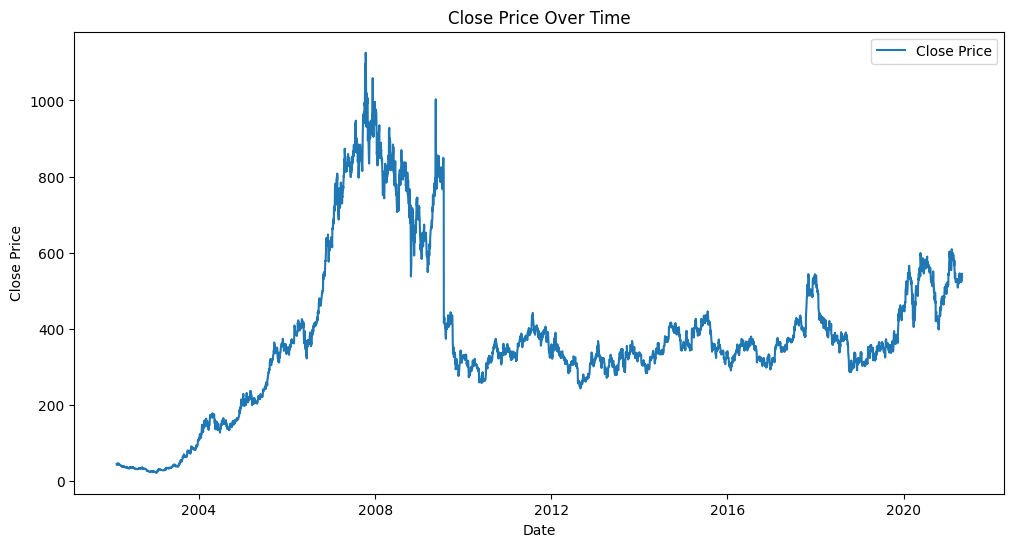

In [26]:
plt.figure(figsize=(12,6))
plt.plot(df['DateTime'], df['Close'], label='Close Price')
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

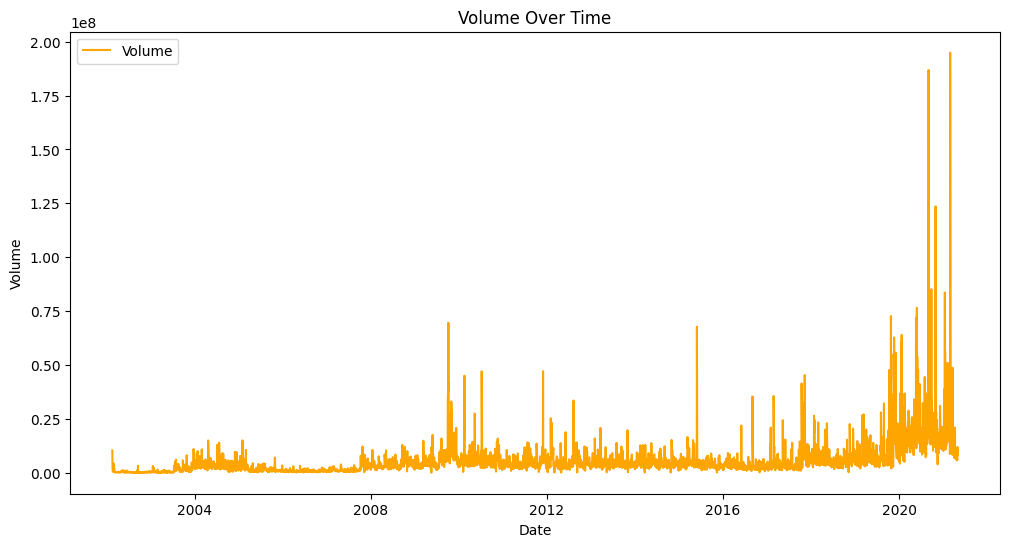

In [27]:
# Another Feature 
plt.figure(figsize=(12,6))
plt.plot(df['DateTime'], df['Volume'], label='Volume', color='orange')
plt.title('Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()

In [28]:
# Convert df to numpy array
data = numeric_df.values.astype(np.float32)
print("Data shape:", data.shape)

Data shape: (4774, 11)


In [29]:
data

array([[0.0000000e+00, 5.1900002e+01, 5.1900002e+01, ..., 4.7754315e+13,
        4.7549000e+04, 6.5037750e+06],
       [4.4349998e+01, 4.5150002e+01, 4.5150002e+01, ..., 1.5126094e+13,
        4.7549000e+04, 1.7411840e+06],
       [4.1700001e+01, 4.0599998e+01, 4.2799999e+01, ..., 1.0443478e+13,
        4.7549000e+04, 1.7411840e+06],
       ...,
       [5.3429999e+02, 5.3595001e+02, 5.4800000e+02, ..., 6.4978661e+14,
        1.2560000e+05, 4.3442430e+06],
       [5.4429999e+02, 5.4970001e+02, 5.5000000e+02, ..., 4.7136937e+14,
        9.8579000e+04, 3.1383840e+06],
       [5.4084998e+02, 5.3350000e+02, 5.4700000e+02, ..., 4.4238885e+14,
        1.0658000e+05, 3.0451080e+06]], shape=(4774, 11), dtype=float32)

In [30]:
INPUT_STEPS = 10
OUTPUT_STEPS = 5
TRAIN_RATIO = 0.8
BATCH_SIZE = 4

##### Train/Test split

In [33]:
# Train/Test split: 80-20
split_idx = int(len(data) * TRAIN_RATIO)
train_data1 = data[:split_idx]
test_data = data[split_idx:]

val_split_idx = int(len(train_data1) * 0.8)
train_data = train_data1[:val_split_idx]
val_data = train_data1[val_split_idx:]

In [34]:
train_data.shape, val_data.shape, test_data.shape

((3055, 11), (764, 11), (955, 11))

In [42]:
scaler = StandardScaler()

scaled_train_data = scaler.fit_transform(train_data)
scaled_test_data = scaler.transform(test_data)
scaled_val_data = scaler.transform(val_data)

In [39]:
scaled_train_data

array([[-1.4673073 , -1.2620604 , -1.2626697 , ..., -0.5386697 ,
        -0.22368377,  1.9327475 ],
       [-1.2913902 , -1.288771  , -1.288827  , ..., -0.73436254,
        -0.22368377, -0.08600037],
       [-1.3019015 , -1.306776  , -1.2979336 , ..., -0.76244724,
        -0.22368377, -0.08600037],
       ...,
       [-0.20772481, -0.19659898, -0.20145798, ...,  0.19126338,
         1.7354486 ,  0.58431417],
       [-0.20117988, -0.1912568 , -0.20436434, ..., -0.29329705,
         0.54226637, -0.16638379],
       [-0.18531363, -0.17978111, -0.20048918, ..., -0.23811515,
        -1.216802  , -0.01739816]], shape=(3055, 11), dtype=float32)

### Create Time-Series Sequences

Examples :

- input : last 10 days
- output : next 5 days



In [37]:
def create_sequences(data, input_steps=10, output_steps=5, overlap=1):
    X, y = [], []
    total_len = len(data)

    stride = input_steps - overlap
    if stride <= 0:
        raise ValueError("Overlap must be less than input_steps to ensure a positive stride.")
    for i in range(0, len(data) - input_steps - output_steps, stride):
        X.append(data[i:i+input_steps])
        y.append(data[i+input_steps:i+input_steps+output_steps])  
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)



In [43]:
# Preparing train/test data with chunking

X_train, y_train = create_sequences(scaled_train_data, INPUT_STEPS, OUTPUT_STEPS,overlap=8)  # input_steps=10, output_steps=5
X_test , y_test  = create_sequences(scaled_test_data, INPUT_STEPS, OUTPUT_STEPS,overlap=8)  # input_steps=10, output_steps=5
print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

X_val, y_val = create_sequences(scaled_val_data, INPUT_STEPS, OUTPUT_STEPS,overlap=8)  # input_steps=10, output_steps=5
print("Validation shapes:", X_val.shape, y_val.shape)


Train shapes: (1520, 10, 11) (1520, 5, 11)
Test shapes: (470, 10, 11) (470, 5, 11)
Validation shapes: (375, 10, 11) (375, 5, 11)


### Convert to pytorch Tensors

In [44]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

#### Dataset and DataLoader

In [55]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]
    
train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=32, shuffle=False)
val_loader = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size=32, shuffle=False)

train_loader.dataset.X.shape, train_loader.dataset.Y.shape

(torch.Size([1520, 10, 11]), torch.Size([1520, 5, 11]))

In [56]:
train_loader.dataset.X

tensor([[[-1.4673e+00, -1.2621e+00, -1.2627e+00,  ..., -5.3867e-01,
          -2.2368e-01,  1.9327e+00],
         [-1.2914e+00, -1.2888e+00, -1.2888e+00,  ..., -7.3436e-01,
          -2.2368e-01, -8.6000e-02],
         [-1.3019e+00, -1.3068e+00, -1.2979e+00,  ..., -7.6245e-01,
          -2.2368e-01, -8.6000e-02],
         ...,
         [-1.2944e+00, -1.2935e+00, -1.2844e+00,  ..., -7.3675e-01,
          -2.2368e-01, -2.4038e-01],
         [-1.2902e+00, -1.2854e+00, -1.2824e+00,  ..., -7.0691e-01,
          -2.2368e-01, -1.5297e-01],
         [-1.3027e+00, -1.3012e+00, -1.2956e+00,  ..., -8.0104e-01,
          -2.2368e-01, -6.2336e-01]],

        [[-1.3019e+00, -1.3068e+00, -1.2979e+00,  ..., -7.6245e-01,
          -2.2368e-01, -8.6000e-02],
         [-1.3037e+00, -1.2979e+00, -1.2956e+00,  ..., -7.9076e-01,
          -2.2368e-01, -6.1806e-01],
         [-1.2991e+00, -1.2987e+00, -1.2948e+00,  ..., -8.0428e-01,
          -2.2368e-01, -6.5486e-01],
         ...,
         [-1.3027e+00, -1

#### LSTM Model (Multi-Output)

In [62]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=len(features_names), hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, 5*len(features_names))  # hidden_size to output_size*input_size

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.view(-1, 5, len(features_names))  # reshape to (batch_size, output_steps, features)

In [ ]:
## Initialize Model, Loss, Optimizer

model = LSTMModel().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        
        output = model(X_batch)
        loss = criterion(output, Y_batch)
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [65]:
epochs = 50

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        
        output = model(X_batch)
        loss = criterion(output, Y_batch)
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 10.6070
Epoch 2, Loss: 10.4510
Epoch 3, Loss: 10.3644
Epoch 4, Loss: 10.4631
Epoch 5, Loss: 10.2957
Epoch 6, Loss: 10.2812
Epoch 7, Loss: 10.3631
Epoch 8, Loss: 10.1864
Epoch 9, Loss: 10.1619
Epoch 10, Loss: 9.9761
Epoch 11, Loss: 10.0051
Epoch 12, Loss: 10.0997
Epoch 13, Loss: 9.9800
Epoch 14, Loss: 9.6577
Epoch 15, Loss: 9.8969
Epoch 16, Loss: 9.9717
Epoch 17, Loss: 9.7293
Epoch 18, Loss: 9.7062
Epoch 19, Loss: 10.0448
Epoch 20, Loss: 10.4076
Epoch 21, Loss: 9.6101
Epoch 22, Loss: 9.5553
Epoch 23, Loss: 9.2818
Epoch 24, Loss: 9.3935
Epoch 25, Loss: 9.2541
Epoch 26, Loss: 9.1710
Epoch 27, Loss: 9.1179
Epoch 28, Loss: 9.0040
Epoch 29, Loss: 8.9710
Epoch 30, Loss: 8.9275
Epoch 31, Loss: 8.9465
Epoch 32, Loss: 8.8005
Epoch 33, Loss: 8.7502
Epoch 34, Loss: 8.6898
Epoch 35, Loss: 8.8486
Epoch 36, Loss: 8.8356
Epoch 37, Loss: 8.7752
Epoch 38, Loss: 8.6368
Epoch 39, Loss: 8.5157
Epoch 40, Loss: 8.4406
Epoch 41, Loss: 8.3834
Epoch 42, Loss: 8.3641
Epoch 43, Loss: 8.2269
Epoch 4

In [71]:
# Evaluation Metrics 

model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        outputs = model(X_batch)
        predictions.append(outputs.numpy())
        actuals.append(Y_batch.numpy())

predictions = np.vstack(predictions)
actuals = np.vstack(actuals)

# Flatten for metric calculation
pred_flat = predictions.reshape(-1, 11)
actual_flat = actuals.reshape(-1, 11)



In [72]:
# Inverse Transform Predictions and Actuals

pred_original = scaler.inverse_transform(pred_flat)
actual_original = scaler.inverse_transform(actual_flat)

pred_original  , actual_original

(array([[-0.02173065,  0.00618855, -0.00407548, ..., -0.06779505,
         -1.0604286 , -0.02351311],
        [ 0.01722769, -0.01009049, -0.02075875, ...,  0.0820269 ,
         -0.67016345,  0.09218663],
        [-0.02000445,  0.00918131, -0.01428576, ...,  0.04541902,
         -0.574663  ,  0.23080328],
        ...,
        [ 0.78271455,  0.76291704,  0.7032493 , ...,  0.9839716 ,
          1.4483563 ,  0.16991489],
        [ 0.75921696,  0.5988982 ,  0.70782596, ...,  1.551803  ,
          2.2102299 ,  1.1458898 ],
        [ 0.8617307 ,  0.8490563 ,  0.5804022 , ...,  0.35028756,
          1.3787798 , -0.32697743]], shape=(2350, 11), dtype=float32),
 array([[ 0.02531082,  0.02262691,  0.01981346, ..., -0.33235416,
         -1.2669417 , -0.34517717],
        [ 0.04514364,  0.05210769,  0.03802663, ...,  0.18496333,
         -0.7550988 ,  0.5585353 ],
        [ 0.06338986,  0.06833201,  0.12560518, ..., -0.36425006,
         -2.0376198 , -0.45029843],
        ...,
        [ 0.60561913,

#### Metrics


In [73]:
mse = mean_squared_error(actual_original, pred_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_original, pred_original)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 6.47105073928833
RMSE: 2.5438260041300644
MAE: 0.834270715713501


### Plot Predictions vs Actual

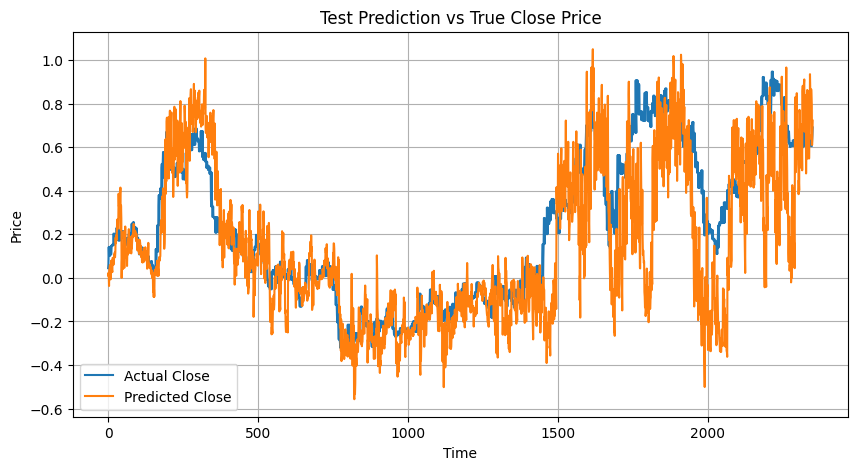

In [75]:
# Example : Plot Close Price
# Plot prediction vs actual for Close Price (index 5)
PLOT_FEATURE = "Close" 
if PLOT_FEATURE not in features_names:
    raise ValueError(f"Feature '{PLOT_FEATURE}' not found in features_names.")
feature_idx = features_names.index(PLOT_FEATURE)

plt.figure(figsize=(10,5))

plt.plot(actual_original[:, feature_idx], label='Actual Close')
plt.plot(pred_original[:, feature_idx], label='Predicted Close')

plt.legend()
plt.title('Test Prediction vs True Close Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.grid(True)
plt.show()